## Figure 2c
## Supplementary Figure 10c, d, 12a, 15a

## Helper codes: run below cells before any of the other cells. 

In [1]:
from pynwb import NWBHDF5IO
from scipy.io import savemat, loadmat
import mat73
import hdf5storage as st
import pickle
import os
import gzip

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import Isomap

from scipy.sparse.linalg import eigsh
from scipy.stats import wilcoxon, mannwhitneyu, sem, linregress
from scipy.spatial.distance import cdist

import seaborn as sns
from copy import deepcopy as dc
from statsmodels.stats.multitest import multipletests

from itertools import combinations, product
import math

# # tell pandas to show all columns when we display a DataFrame
# pd.set_option("display.max_columns", None)

In [2]:
# loading variables

# ABO Neuropixels
with gzip.open('resp_matrix_ep_RS_all_32sess_allensdk.pickle.gz', 'rb') as f:
    resp_matrix_ep_RS_all = pickle.load(f)

    list_rate_RS = resp_matrix_ep_RS_all['list_rate_RS'].copy()
    list_rate_RS_dr = resp_matrix_ep_RS_all['list_rate_RS_dr'].copy()
    list_rate_all = resp_matrix_ep_RS_all['list_rate_all'].copy()
    list_rate_all_dr = resp_matrix_ep_RS_all['list_rate_all_dr'].copy()
    list_slopes_RS_an_loglog = resp_matrix_ep_RS_all['list_slopes_RS_an_loglog'].copy()
    list_slopes_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_all_an_loglog'].copy()
    list_slopes_stat_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_stat_all_an_loglog'].copy()
    list_slopes_mov_all_an_loglog = resp_matrix_ep_RS_all['list_slopes_mov_all_an_loglog'].copy()

    sess_inds_qual_RS = resp_matrix_ep_RS_all['sess_inds_qual_RS'].copy()
    sess_inds_qual_RS_dr = resp_matrix_ep_RS_all['sess_inds_qual_RS_dr'].copy()
    sess_inds_qual_all = resp_matrix_ep_RS_all['sess_inds_qual_all'].copy()
    sess_inds_qual_all_dr = resp_matrix_ep_RS_all['sess_inds_qual_all_dr'].copy()

with gzip.open('invalid_unit_sess.pickle.gz', 'rb') as f:
    invalid_unit_sess = pickle.load(f)

    list_invalid_units_visp = invalid_unit_sess['list_invalid_units_visp'].copy()
    list_invalid_units_HVA = invalid_unit_sess['list_invalid_units_HVA'].copy()
    list_invalid_sess_visp = invalid_unit_sess['list_invalid_sess_visp'].copy()
    list_invalid_sess_HVA = invalid_unit_sess['list_invalid_sess_HVA'].copy()
    sess_inds_mapBO = invalid_unit_sess['sess_inds_mapBO'].copy()

In [3]:
def annotate_lineplot_significance(significant_values, axes, ax_ind, line_height_ratio, color):

    if len(significant_values) > 0:

        # Initialize start and end points of lines
        start = None
        lines = []
        dots = []

        # Loop through sorted significant_values to group them into lines or dots
        for i in range(len(significant_values) - 1):
            if start is None:
                start = significant_values[i]

            # Check if the next value is part of the same line
            if significant_values[i + 1] - significant_values[i] > 0.1 + 1e-9:  # Threshold for a gap; add pseudo-value to avoid floating point issue
                if start == significant_values[i]:
                    dots.append(start)  # Isolated point
                else:
                    lines.append((start, significant_values[i]))  # Line segment
                start = None

        # Check the last value
        if start is None:
            dots.append(significant_values[-1])
        else:
            lines.append((start, significant_values[-1]))

        # Plot lines and dots
        for line in lines:
            if isinstance(axes, np.ndarray):
                axes[ax_ind].hlines(axes[ax_ind].get_ylim()[0]+(axes[ax_ind].get_ylim()[1]-axes[ax_ind].get_ylim()[0])*line_height_ratio, \
                    xmin=line[0], xmax=line[1], colors=color)  # Draw a line
            elif isinstance(axes, plt.Axes):
                axes.hlines(axes.get_ylim()[0]+(axes.get_ylim()[1]-axes.get_ylim()[0])*line_height_ratio, \
                    xmin=line[0], xmax=line[1], colors=color)
            else:
                plt.hlines(plt.gca().get_ylim()[0]+(plt.gca().get_ylim()[1]-plt.gca().get_ylim()[0])*line_height_ratio, \
                    xmin=line[0], xmax=line[1], colors=color)
                
        for dot in dots:
            if isinstance(axes, np.ndarray):
                axes[ax_ind].hlines(axes[ax_ind].get_ylim()[0]+(axes[ax_ind].get_ylim()[1]-axes[ax_ind].get_ylim()[0])*line_height_ratio, \
                    xmin=dot-0.01, xmax=dot+0.01, colors=color)  # Draw a very short line
            elif isinstance(axes, plt.Axes):
                axes.hlines(axes.get_ylim()[0]+(axes.get_ylim()[1]-axes.get_ylim()[0])*line_height_ratio, \
                    xmin=dot-0.01, xmax=dot+0.01, colors=color)
            else:
                plt.hlines(plt.gca().get_ylim()[0]+(plt.gca().get_ylim()[1]-plt.gca().get_ylim()[0])*line_height_ratio, \
                    xmin=dot-0.01, xmax=dot+0.01, colors=color)

In [4]:
def compute_mean_var_trial(label_cnt_dict, rate_sorted):    
    list_trial_mean = [[0]] * len(label_cnt_dict)
    list_trial_var = [[0]] * len(label_cnt_dict)

    for trial_ind, trial_type in enumerate(label_cnt_dict):
        
        trial_rate = np.array(rate_sorted.loc[:, trial_type])                
        trial_mean = np.mean(trial_rate, axis=1)
        trial_var = np.var(trial_rate, axis=1, ddof=1)

        trial_mean = pd.DataFrame(trial_mean, columns=[trial_type], index=rate_sorted.index)
        trial_var = pd.DataFrame(trial_var, columns=[trial_type], index=rate_sorted.index)
        list_trial_mean[trial_ind] = pd.concat([trial_mean] * label_cnt_dict[trial_type], axis=1)
        list_trial_var[trial_ind] = pd.concat([trial_var] * label_cnt_dict[trial_type], axis=1)

    rate_sorted_mean = pd.concat(list_trial_mean, axis=1)
    rate_sorted_var = pd.concat(list_trial_var, axis=1)

    return rate_sorted_mean, rate_sorted_var

In [5]:
def compute_mean_var_trial_collapse(label_cnt_dict, rate_sorted):    
    list_trial_mean = [[0]] * len(label_cnt_dict)
    list_trial_var = [[0]] * len(label_cnt_dict)

    for trial_ind, trial_type in enumerate(label_cnt_dict):
        
        trial_rate = np.array(rate_sorted.loc[:, trial_type])                
        trial_mean = np.mean(trial_rate, axis=1, dtype=np.longdouble)
        trial_var = np.var(trial_rate, axis=1, ddof=1, dtype=np.longdouble)

        trial_mean = pd.DataFrame(trial_mean, columns=[trial_type], index=rate_sorted.index)
        trial_var = pd.DataFrame(trial_var, columns=[trial_type], index=rate_sorted.index)
        list_trial_mean[trial_ind] = trial_mean.copy()
        list_trial_var[trial_ind] = trial_var.copy()

    rate_sorted_mean = pd.concat(list_trial_mean, axis=1)
    rate_sorted_var = pd.concat(list_trial_var, axis=1)

    return rate_sorted_mean, rate_sorted_var

## Codes for figures

## Figure 2c

In [6]:
# # Collect effective dimensionality for each session
# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)
# num_sess = 32
# num_trial_types = 119
# n_trial_sampling = 100

# list_dim_asis = np.zeros((num_sess, num_trial_types))
# list_dim_RRneuron2 = np.zeros((num_sess, len(list_target_slopes), num_trial_types))
# list_dim_global_asis = np.zeros((num_sess, 2))
# list_dim_global_RRneuron2 = np.zeros((num_sess, len(list_target_slopes), 2))
# list_dim_sam_asis = np.zeros((num_sess, n_trial_sampling))
# list_dim_sam_RRneuron2 = np.zeros((num_sess, len(list_target_slopes), n_trial_sampling))
# for sess_ind in range(num_sess):
#     file_name = 'eff_dim_DC_ABO_' + str(sess_ind) + '.pickle.gz'
#     file_name = 'eff_dim_DC_ABO_shuf_' + str(sess_ind) + '.pickle.gz'
    
#     with gzip.open(file_name, 'rb') as f:
#         eff_dim_DC_ABO = pickle.load(f)
#         list_dim_asis[sess_ind] = eff_dim_DC_ABO['list_dim_asis'].copy()
#         list_dim_RRneuron2[sess_ind] = eff_dim_DC_ABO['list_dim_RRneuron'].copy()
#         list_dim_global_asis[sess_ind] = eff_dim_DC_ABO['list_dim_global_asis'].copy()
#         list_dim_global_RRneuron2[sess_ind] = eff_dim_DC_ABO['list_dim_global_RRneuron'].copy()
#         list_dim_sam_asis[sess_ind] = eff_dim_DC_ABO['list_dim_sam_asis'].copy()
#         list_dim_sam_RRneuron2[sess_ind] = eff_dim_DC_ABO['list_dim_sam_RRneuron'].copy()

# save_file_name = 'eff_dim_DC_ABO3.pickle.gz'
# save_file_name = 'eff_dim_DC_ABO_shuf2.pickle.gz'
# with gzip.open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_dim_asis', 'list_dim_RRneuron2', 'list_dim_global_asis', 'list_dim_global_RRneuron2', 'list_dim_sam_asis', 'list_dim_sam_RRneuron2'],
#                 'list_dim_asis': list_dim_asis, 'list_dim_RRneuron2': list_dim_RRneuron2, 'list_dim_global_asis': list_dim_global_asis, 'list_dim_global_RRneuron2': list_dim_global_RRneuron2,
#                 'list_dim_sam_asis': list_dim_sam_asis, 'list_dim_sam_RRneuron2': list_dim_sam_RRneuron2}, f)

c:\Users\USER\anaconda3\envs\allensdk_ep_mod_test\Lib\site-packages\scipy\stats\_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


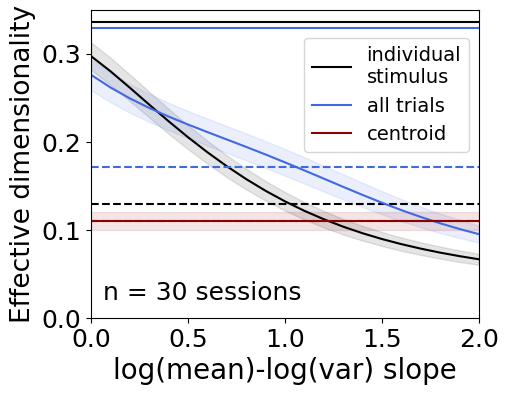

In [7]:
# effective dimensionality plot

save_filename = 'eff_dim_DC_ABO3.pickle.gz' # all trials, centroid, trial sampling (n_trial_sampling=100), math corrected
with gzip.open(save_filename, 'rb') as f:
    eff_dim_ABO = pickle.load(f)

    list_dim_asis = eff_dim_ABO['list_dim_asis'].copy()
    list_dim_RRneuron2 = eff_dim_ABO['list_dim_RRneuron2'].copy()
    list_dim_global_asis = eff_dim_ABO['list_dim_global_asis'].copy()
    list_dim_global_RRneuron2 = eff_dim_ABO['list_dim_global_RRneuron2'].copy()
    list_dim_sam_asis = eff_dim_ABO['list_dim_sam_asis'].copy()
    list_dim_sam_RRneuron2 = eff_dim_ABO['list_dim_sam_RRneuron2'].copy()

num_sess = 32
list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# exclude session 0, 6
bool_sess = ~np.isin(range(num_sess), [0, 6])

list_dim_asis = list_dim_asis[bool_sess]
list_dim_RRneuron2 = list_dim_RRneuron2[bool_sess]
list_dim_global_asis = list_dim_global_asis[bool_sess]
list_dim_global_RRneuron2 = list_dim_global_RRneuron2[bool_sess]
list_dim_sam_asis = list_dim_sam_asis[bool_sess]
list_dim_sam_RRneuron2 = list_dim_sam_RRneuron2[bool_sess]

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# 1. not shuffled

# line plot

# individual manifold
list_means_dim = np.nanmean(list_dim_RRneuron2, axis=(0, 2))
list_errs_dim = sem(np.nanmean(list_dim_RRneuron2, axis=2), axis=0)

axes[0].plot(list_target_slopes, list_means_dim, color='k', label='individual\nstimulus')
axes[0].fill_between(list_target_slopes, list_means_dim-list_errs_dim, list_means_dim+list_errs_dim, color='k', alpha=0.1)

axes[0].axhline(np.nanmean(list_dim_asis), color='k', linestyle='--') # as-is average

# global manifold
list_colors_glo = ['royalblue', 'darkred']
glo_ind = 0
list_means_dim_global = np.nanmean(list_dim_global_RRneuron2[:, :, glo_ind], axis=0)
list_errs_dim_global = sem(list_dim_global_RRneuron2[:, :, glo_ind], axis=0)

axes[0].plot(list_target_slopes, list_means_dim_global, color=list_colors_glo[glo_ind], label='all trials')
axes[0].fill_between(list_target_slopes, list_means_dim_global-list_errs_dim_global, list_means_dim_global+list_errs_dim_global, color=list_colors_glo[glo_ind], alpha=0.1)

axes[0].axhline(np.nanmean(list_dim_global_asis[:, glo_ind]), color=list_colors_glo[glo_ind], linestyle='--') # as-is average

glo_ind = 1
list_means_dim_global = np.nanmean(list_dim_global_RRneuron2[:, :, glo_ind], axis=0)
list_errs_dim_global = sem(list_dim_global_RRneuron2[:, :, glo_ind], axis=0)

axes[0].plot(list_target_slopes, list_means_dim_global, color=list_colors_glo[glo_ind], label='centroid')
axes[0].fill_between(list_target_slopes, list_means_dim_global-list_errs_dim_global, list_means_dim_global+list_errs_dim_global, color=list_colors_glo[glo_ind], alpha=0.1)

axes[0].axhline(np.nanmean(list_dim_global_asis[:, glo_ind]), color=list_colors_glo[glo_ind], linestyle='--') # as-is average

# significance
axes[0].set_ylim(0, 0.35) # w/o shuffled
list_pvals_dim_ABO = np.zeros(len(list_target_slopes))
for slope_ind, target_slope in enumerate(list_target_slopes):
    list_pvals_dim_ABO[slope_ind] = list(wilcoxon(np.nanmean(list_dim_asis, axis=1),
                                                  np.nanmean(list_dim_RRneuron2[:, slope_ind], axis=1), nan_policy='omit'))[1]
list_pvals_dim_ABO = np.array(multipletests(list_pvals_dim_ABO, method='holm')[1]) # multiple comparisons correction
list_sig_slopes_dim = list_target_slopes[list_pvals_dim_ABO < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_dim, axes=axes, ax_ind=0, line_height_ratio=0.96, color='k')

for glo_ind in [0, 1]:
    # if glo_ind == 1:
        list_pvals_dim_glo_ABO = np.zeros(len(list_target_slopes))
        for slope_ind, target_slope in enumerate(list_target_slopes):
            list_pvals_dim_glo_ABO[slope_ind] = list(wilcoxon(list_dim_global_asis[:, glo_ind], list_dim_global_RRneuron2[:, slope_ind, glo_ind], nan_policy='omit'))[1]
        list_pvals_dim_glo_ABO = np.array(multipletests(list_pvals_dim_glo_ABO, method='holm')[1]) # multiple comparisons correction
        list_sig_slopes_dim_glo = list_target_slopes[list_pvals_dim_glo_ABO < 0.05].copy()
        annotate_lineplot_significance(list_sig_slopes_dim_glo, axes=None, ax_ind=None, line_height_ratio=0.94-0.02*glo_ind, color=list_colors_glo[glo_ind])
        # height = (np.nanmean(list_dim_global_asis[:, glo_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
        # # axes[0].annotate('as-is', xy=(0.82, height+0.03), xycoords='axes fraction', fontsize=18, color='b')
        # axes[0].annotate('as-is', xy=(0.79, height+0.03), xycoords='axes fraction', fontsize=18, color='k') # w/ shuffled

axes[0].set_xlim(0, 2)
# axes[0].legend(loc='upper right', prop={'size': 14})
axes[0].legend(loc='upper right', bbox_to_anchor=(1, 0.94), prop={'size': 14})
# # axes[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1), prop={'size': 14})
# axes[0].annotate(f'n = {list_dim_asis.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('Effective dimensionality', fontsize=19)
axes[0].tick_params('both', labelsize=18)

axes[0].annotate(f'n = {list_dim_asis.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')

# # plt.savefig('code_images\\svg\\effdim_indglocen.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\effdim_indglocen.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\svg\\effdim_censam.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\effdim_censam.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\neural_variability_robustness\\svg\\effdim.svg', bbox_inches='tight')
# # plt.savefig('code_images\\neural_variability_robustness\\png\\effdim.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 10c

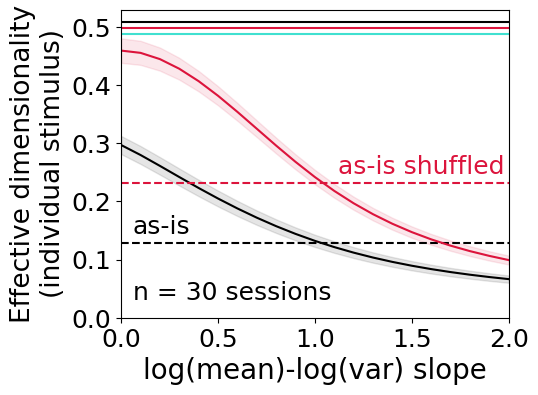

In [8]:
# effective dimensionality plot (w/ shuffled) (individual stimulus)

save_filename = 'eff_dim_DC_ABO3.pickle.gz' # all trials, centroid, trial sampling (n_trial_sampling=100), math corrected
with gzip.open(save_filename, 'rb') as f:
    eff_dim_ABO = pickle.load(f)

    list_dim_asis = eff_dim_ABO['list_dim_asis'].copy()
    list_dim_RRneuron2 = eff_dim_ABO['list_dim_RRneuron2'].copy()
    list_dim_global_asis = eff_dim_ABO['list_dim_global_asis'].copy()
    list_dim_global_RRneuron2 = eff_dim_ABO['list_dim_global_RRneuron2'].copy()
    list_dim_sam_asis = eff_dim_ABO['list_dim_sam_asis'].copy()
    list_dim_sam_RRneuron2 = eff_dim_ABO['list_dim_sam_RRneuron2'].copy()

save_filename = 'eff_dim_DC_ABO_shuf2.pickle.gz' # all trials, centroid, trial sampling (n_trial_sampling=100), math corrected
with gzip.open(save_filename, 'rb') as f:
    eff_dim_ABO = pickle.load(f)

    list_dim_asis_shuf = eff_dim_ABO['list_dim_asis'].copy()
    list_dim_RRneuron2_shuf = eff_dim_ABO['list_dim_RRneuron2'].copy()
    list_dim_global_asis_shuf = eff_dim_ABO['list_dim_global_asis'].copy()
    list_dim_global_RRneuron2_shuf = eff_dim_ABO['list_dim_global_RRneuron2'].copy()
    list_dim_sam_asis_shuf = eff_dim_ABO['list_dim_sam_asis'].copy()
    list_dim_sam_RRneuron2_shuf = eff_dim_ABO['list_dim_sam_RRneuron2'].copy()

num_sess = 32
list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# exclude session 0, 6
bool_sess = ~np.isin(range(num_sess), [0, 6])

list_dim_asis = list_dim_asis[bool_sess]
list_dim_RRneuron2 = list_dim_RRneuron2[bool_sess]
list_dim_global_asis = list_dim_global_asis[bool_sess]
list_dim_global_RRneuron2 = list_dim_global_RRneuron2[bool_sess]
list_dim_sam_asis = list_dim_sam_asis[bool_sess]
list_dim_sam_RRneuron2 = list_dim_sam_RRneuron2[bool_sess]

list_dim_asis_shuf = list_dim_asis_shuf[bool_sess]
list_dim_RRneuron2_shuf = list_dim_RRneuron2_shuf[bool_sess]
list_dim_global_asis_shuf = list_dim_global_asis_shuf[bool_sess]
list_dim_global_RRneuron2_shuf = list_dim_global_RRneuron2_shuf[bool_sess]
list_dim_sam_asis_shuf = list_dim_sam_asis_shuf[bool_sess]
list_dim_sam_RRneuron2_shuf = list_dim_sam_RRneuron2_shuf[bool_sess]

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# # 1. not shuffled

# # line plot

# individual manifold
list_means_dim = np.nanmean(list_dim_RRneuron2, axis=(0, 2))
list_errs_dim = sem(np.nanmean(list_dim_RRneuron2, axis=2), axis=0)

axes[0].plot(list_target_slopes, list_means_dim, color='k', label='individual\nstimulus')
axes[0].fill_between(list_target_slopes, list_means_dim-list_errs_dim, list_means_dim+list_errs_dim, color='k', alpha=0.1)

axes[0].axhline(np.nanmean(list_dim_asis), color='k', linestyle='--') # as-is average

# 2. shuffled

# # line plot

# individual manifold
list_means_dim = np.nanmean(list_dim_RRneuron2_shuf, axis=(0, 2))
list_errs_dim = sem(np.nanmean(list_dim_RRneuron2_shuf, axis=2), axis=0)

axes[0].plot(list_target_slopes, list_means_dim, color='crimson', label='individual\nstimulus (shuffled)')
axes[0].fill_between(list_target_slopes, list_means_dim-list_errs_dim, list_means_dim+list_errs_dim, color='crimson', alpha=0.1)

axes[0].axhline(np.nanmean(list_dim_asis_shuf), color='crimson', linestyle='--') # as-is average

# significance
axes[0].set_ylim(0, 0.53) # w/ shuffled
list_pvals_dim_ABO = np.zeros(len(list_target_slopes))
list_pvals_dim_ABO_shuf = np.zeros(len(list_target_slopes))
list_pvals_dim_ABO_toshuf = np.zeros(len(list_target_slopes))
for slope_ind, target_slope in enumerate(list_target_slopes):
    list_pvals_dim_ABO[slope_ind] = list(wilcoxon(np.nanmean(list_dim_asis, axis=1),
                                                  np.nanmean(list_dim_RRneuron2[:, slope_ind], axis=1), nan_policy='omit'))[1]
    list_pvals_dim_ABO_shuf[slope_ind] = list(wilcoxon(np.nanmean(list_dim_asis_shuf, axis=1),
                                                       np.nanmean(list_dim_RRneuron2_shuf[:, slope_ind], axis=1), nan_policy='omit'))[1]
    list_pvals_dim_ABO_toshuf[slope_ind] = list(wilcoxon(np.nanmean(list_dim_RRneuron2[:, slope_ind], axis=1),
                                                         np.nanmean(list_dim_RRneuron2_shuf[:, slope_ind], axis=1), nan_policy='omit'))[1]    
list_pvals_dim_ABO = np.array(multipletests(list_pvals_dim_ABO, method='holm')[1]) # multiple comparisons correction
list_sig_slopes_dim = list_target_slopes[list_pvals_dim_ABO < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_dim, axes=axes, ax_ind=0, line_height_ratio=0.96, color='k')
list_pvals_dim_ABO_shuf = np.array(multipletests(list_pvals_dim_ABO_shuf, method='holm')[1]) # multiple comparisons correction
list_sig_slopes_dim_shuf = list_target_slopes[list_pvals_dim_ABO_shuf < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_dim_shuf, axes=axes, ax_ind=0, line_height_ratio=0.94, color='crimson')
list_pvals_dim_ABO_toshuf = np.array(multipletests(list_pvals_dim_ABO_toshuf, method='holm')[1]) # multiple comparisons correction
list_sig_slopes_dim_toshuf = list_target_slopes[list_pvals_dim_ABO_toshuf < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_dim_toshuf, axes=axes, ax_ind=0, line_height_ratio=0.92, color='turquoise')

height = (np.nanmean(list_dim_asis)-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
# axes[0].annotate('as-is', xy=(0.82, height+0.03), xycoords='axes fraction', fontsize=18, color='b')
axes[0].annotate('as-is', xy=(0.03, height+0.03), xycoords='axes fraction', fontsize=18, color='k') # w/ shuffled
height_shuf = (np.nanmean(list_dim_asis_shuf)-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
axes[0].annotate('as-is shuffled', xy=(0.56, height_shuf+0.03), xycoords='axes fraction', fontsize=18, color='crimson')

axes[0].set_xlim(0, 2)

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('Effective dimensionality\n(individual stimulus)', fontsize=19)
# axes[0].set_ylabel('Effective dimensionality\n(all trials)', fontsize=19)
axes[0].tick_params('both', labelsize=18)

axes[0].annotate(f'n = {list_dim_asis.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')
# axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1), prop={'size': 14})

# # plt.savefig('code_images\\svg\\shuf_effdim_indglocen.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\shuf_effdim_indglocen.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\shuf_effdim_glo.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\shuf_effdim_glo.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\effdim_censam.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\effdim_censam.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\neural_variability_robustness\\svg\\effdim.svg', bbox_inches='tight')
# # plt.savefig('code_images\\neural_variability_robustness\\png\\effdim.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\neural_variability_robustness\\svg\\shuf_effdim.svg', bbox_inches='tight')
# plt.savefig('code_images\\neural_variability_robustness\\png\\shuf_effdim.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 10d

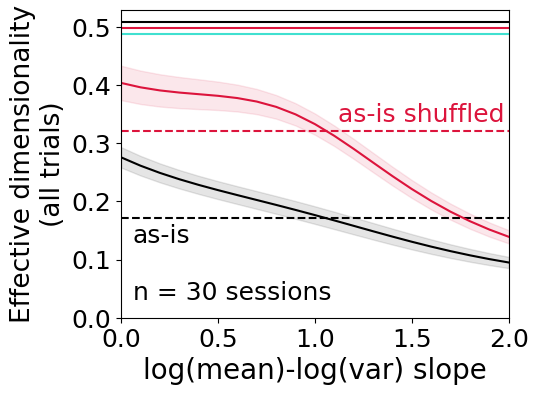

In [9]:
# effective dimensionality plot (w/ shuffled) (global)

save_filename = 'eff_dim_DC_ABO3.pickle.gz' # all trials, centroid, trial sampling (n_trial_sampling=100), math corrected
with gzip.open(save_filename, 'rb') as f:
    eff_dim_ABO = pickle.load(f)

    list_dim_asis = eff_dim_ABO['list_dim_asis'].copy()
    list_dim_RRneuron2 = eff_dim_ABO['list_dim_RRneuron2'].copy()
    list_dim_global_asis = eff_dim_ABO['list_dim_global_asis'].copy()
    list_dim_global_RRneuron2 = eff_dim_ABO['list_dim_global_RRneuron2'].copy()
    list_dim_sam_asis = eff_dim_ABO['list_dim_sam_asis'].copy()
    list_dim_sam_RRneuron2 = eff_dim_ABO['list_dim_sam_RRneuron2'].copy()

save_filename = 'eff_dim_DC_ABO_shuf2.pickle.gz' # all trials, centroid, trial sampling (n_trial_sampling=100), math corrected
with gzip.open(save_filename, 'rb') as f:
    eff_dim_ABO = pickle.load(f)

    list_dim_asis_shuf = eff_dim_ABO['list_dim_asis'].copy()
    list_dim_RRneuron2_shuf = eff_dim_ABO['list_dim_RRneuron2'].copy()
    list_dim_global_asis_shuf = eff_dim_ABO['list_dim_global_asis'].copy()
    list_dim_global_RRneuron2_shuf = eff_dim_ABO['list_dim_global_RRneuron2'].copy()
    list_dim_sam_asis_shuf = eff_dim_ABO['list_dim_sam_asis'].copy()
    list_dim_sam_RRneuron2_shuf = eff_dim_ABO['list_dim_sam_RRneuron2'].copy()

num_sess = 32
list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# exclude session 0, 6
bool_sess = ~np.isin(range(num_sess), [0, 6])

list_dim_asis = list_dim_asis[bool_sess]
list_dim_RRneuron2 = list_dim_RRneuron2[bool_sess]
list_dim_global_asis = list_dim_global_asis[bool_sess]
list_dim_global_RRneuron2 = list_dim_global_RRneuron2[bool_sess]
list_dim_sam_asis = list_dim_sam_asis[bool_sess]
list_dim_sam_RRneuron2 = list_dim_sam_RRneuron2[bool_sess]

list_dim_asis_shuf = list_dim_asis_shuf[bool_sess]
list_dim_RRneuron2_shuf = list_dim_RRneuron2_shuf[bool_sess]
list_dim_global_asis_shuf = list_dim_global_asis_shuf[bool_sess]
list_dim_global_RRneuron2_shuf = list_dim_global_RRneuron2_shuf[bool_sess]
list_dim_sam_asis_shuf = list_dim_sam_asis_shuf[bool_sess]
list_dim_sam_RRneuron2_shuf = list_dim_sam_RRneuron2_shuf[bool_sess]

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# 1. not shuffled

# line plot

# global manifold
list_colors_glo = ['k', 'darkred']
glo_ind = 0
list_means_dim_global = np.nanmean(list_dim_global_RRneuron2[:, :, glo_ind], axis=0)
list_errs_dim_global = sem(list_dim_global_RRneuron2[:, :, glo_ind], axis=0)

axes[0].plot(list_target_slopes, list_means_dim_global, color=list_colors_glo[glo_ind], label='all trials')
axes[0].fill_between(list_target_slopes, list_means_dim_global-list_errs_dim_global, list_means_dim_global+list_errs_dim_global, color=list_colors_glo[glo_ind], alpha=0.1)

axes[0].axhline(np.nanmean(list_dim_global_asis[:, glo_ind]), color=list_colors_glo[glo_ind], linestyle='--') # as-is average

# 2. shuffled

# line plot

# global manifold
list_colors_glo = ['crimson', 'darkred']

glo_ind = 0
list_means_dim_global = np.nanmean(list_dim_global_RRneuron2_shuf[:, :, glo_ind], axis=0)
list_errs_dim_global = sem(list_dim_global_RRneuron2_shuf[:, :, glo_ind], axis=0)

axes[0].plot(list_target_slopes, list_means_dim_global, color=list_colors_glo[glo_ind], label='all trials (shuffled)')
axes[0].fill_between(list_target_slopes, list_means_dim_global-list_errs_dim_global, list_means_dim_global+list_errs_dim_global, color=list_colors_glo[glo_ind], alpha=0.1)

axes[0].axhline(np.nanmean(list_dim_global_asis_shuf[:, glo_ind]), color=list_colors_glo[glo_ind], linestyle='--') # as-is average

# significance
axes[0].set_ylim(0, 0.53) # w/ shuffled
for glo_ind in [0, 1]:
    if glo_ind == 0:
        list_pvals_dim_glo_ABO = np.zeros(len(list_target_slopes))
        list_pvals_dim_glo_ABO_shuf = np.zeros(len(list_target_slopes))
        list_pvals_dim_glo_ABO_toshuf = np.zeros(len(list_target_slopes))
        for slope_ind, target_slope in enumerate(list_target_slopes):
            list_pvals_dim_glo_ABO[slope_ind] = list(wilcoxon(list_dim_global_asis[:, glo_ind], list_dim_global_RRneuron2[:, slope_ind, glo_ind], nan_policy='omit'))[1]
            list_pvals_dim_glo_ABO_shuf[slope_ind] = list(wilcoxon(list_dim_global_asis_shuf[:, glo_ind], list_dim_global_RRneuron2_shuf[:, slope_ind, glo_ind], nan_policy='omit'))[1]
            list_pvals_dim_glo_ABO_toshuf[slope_ind] = list(wilcoxon(list_dim_global_RRneuron2[:, slope_ind, glo_ind], list_dim_global_RRneuron2_shuf[:, slope_ind, glo_ind], nan_policy='omit'))[1]
        list_pvals_dim_glo_ABO = np.array(multipletests(list_pvals_dim_glo_ABO, method='holm')[1]) # multiple comparisons correction
        list_sig_slopes_dim_glo = list_target_slopes[list_pvals_dim_glo_ABO < 0.05].copy()
        annotate_lineplot_significance(list_sig_slopes_dim_glo, axes=None, ax_ind=None, line_height_ratio=0.96, color='k')
        list_pvals_dim_glo_ABO_shuf = np.array(multipletests(list_pvals_dim_glo_ABO_shuf, method='holm')[1]) # multiple comparisons correction
        list_sig_slopes_dim_glo_shuf = list_target_slopes[list_pvals_dim_glo_ABO_shuf < 0.05].copy()
        annotate_lineplot_significance(list_sig_slopes_dim_glo_shuf, axes=None, ax_ind=None, line_height_ratio=0.94-0.02*glo_ind, color=list_colors_glo[glo_ind])
        list_pvals_dim_glo_ABO_toshuf = np.array(multipletests(list_pvals_dim_glo_ABO_toshuf, method='holm')[1]) # multiple comparisons correction
        list_sig_slopes_dim_glo_toshuf = list_target_slopes[list_pvals_dim_glo_ABO_toshuf < 0.05].copy()
        annotate_lineplot_significance(list_sig_slopes_dim_glo_toshuf, axes=None, ax_ind=None, line_height_ratio=0.92, color='turquoise')
        
        height = (np.nanmean(list_dim_global_asis[:, glo_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
        # axes[0].annotate('as-is', xy=(0.82, height+0.03), xycoords='axes fraction', fontsize=18, color='b')
        axes[0].annotate('as-is', xy=(0.03, height-0.08), xycoords='axes fraction', fontsize=18, color='k') # w/ shuffled
        height_shuf = (np.nanmean(list_dim_global_asis_shuf[:, glo_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
        axes[0].annotate('as-is shuffled', xy=(0.56, height_shuf+0.03), xycoords='axes fraction', fontsize=18, color=list_colors_glo[glo_ind])

axes[0].set_xlim(0, 2)

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('Effective dimensionality\n(all trials)', fontsize=19)
axes[0].tick_params('both', labelsize=18)

axes[0].annotate(f'n = {list_dim_asis.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')
# axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1), prop={'size': 14})

# # plt.savefig('code_images\\svg\\shuf_effdim_indglocen.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\shuf_effdim_indglocen.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\shuf_effdim_glo.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\shuf_effdim_glo.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\svg\\effdim_censam.svg', bbox_inches='tight')
# # plt.savefig('code_images\\png\\effdim_censam.png', dpi=300, bbox_inches='tight')
# # plt.savefig('code_images\\neural_variability_robustness\\svg\\effdim.svg', bbox_inches='tight')
# # plt.savefig('code_images\\neural_variability_robustness\\png\\effdim.png', dpi=300, bbox_inches='tight')
# plt.savefig('code_images\\neural_variability_robustness\\svg\\shuf_effdim.svg', bbox_inches='tight')
# plt.savefig('code_images\\neural_variability_robustness\\png\\shuf_effdim.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 12a

In [10]:
# # Collect effective dimensionality for each session (HVA)

# list_HVA_names = ['VISl', 'VISrl', 'VISal', 'VISpm', 'VISam']
# list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# num_sess = 32
# num_trial_types = 119
# n_trial_sampling = 100

# list_dim_asis_HVA = {hva: np.zeros((num_sess, num_trial_types)) for hva in list_HVA_names}
# list_dim_RRneuron_HVA2 = {hva: np.zeros((num_sess, len(list_target_slopes), num_trial_types)) for hva in list_HVA_names}
# list_dim_global_asis_HVA = {hva: np.zeros((num_sess, 2)) for hva in list_HVA_names}
# list_dim_global_RRneuron_HVA2 = {hva: np.zeros((num_sess, len(list_target_slopes), 2)) for hva in list_HVA_names}
# list_dim_sam_asis_HVA = {hva: np.zeros((num_sess, n_trial_sampling)) for hva in list_HVA_names}
# list_dim_sam_RRneuron_HVA2 = {hva: np.zeros((num_sess, len(list_target_slopes), n_trial_sampling)) for hva in list_HVA_names}
# for area_ind, area in enumerate(list_HVA_names):
#     for sess_ind in range(num_sess):
#         file_name = 'eff_dim_DC_ABO_HVA_' + str(sess_ind) + '.pickle.gz'
        
#         with gzip.open(file_name, 'rb') as f:
#             eff_dim_DC_ABO_HVA = pickle.load(f)
#             list_dim_asis_HVA[area][sess_ind] = eff_dim_DC_ABO_HVA['list_dim_asis_HVA'][area].copy()
#             list_dim_RRneuron_HVA2[area][sess_ind] = eff_dim_DC_ABO_HVA['list_dim_RRneuron_HVA'][area].copy()
#             list_dim_global_asis_HVA[area][sess_ind] = eff_dim_DC_ABO_HVA['list_dim_global_asis_HVA'][area].copy()
#             list_dim_global_RRneuron_HVA2[area][sess_ind] = eff_dim_DC_ABO_HVA['list_dim_global_RRneuron_HVA'][area].copy()
#             list_dim_sam_asis_HVA[area][sess_ind] = eff_dim_DC_ABO_HVA['list_dim_sam_asis_HVA'][area].copy()
#             list_dim_sam_RRneuron_HVA2[area][sess_ind] = eff_dim_DC_ABO_HVA['list_dim_sam_RRneuron_HVA'][area].copy()

# save_file_name = 'eff_dim_DC_ABO_HVA2.pickle.gz'
# with gzip.open(save_file_name, 'wb') as f:
#     pickle.dump({'tree_variables': ['list_dim_asis_HVA', 'list_dim_RRneuron_HVA2', 'list_dim_global_asis_HVA',
#                                     'list_dim_global_RRneuron_HVA2', 'list_dim_sam_asis_HVA', 'list_dim_sam_RRneuron_HVA2'],
#                 'list_dim_asis_HVA': list_dim_asis_HVA, 'list_dim_RRneuron_HVA2': list_dim_RRneuron_HVA2, 'list_dim_global_asis_HVA': list_dim_global_asis_HVA,
#                 'list_dim_global_RRneuron_HVA2': list_dim_global_RRneuron_HVA2, 'list_dim_sam_asis_HVA': list_dim_sam_asis_HVA, 'list_dim_sam_RRneuron_HVA2': list_dim_sam_RRneuron_HVA2}, f)

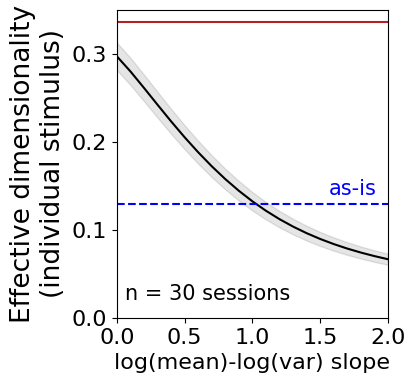

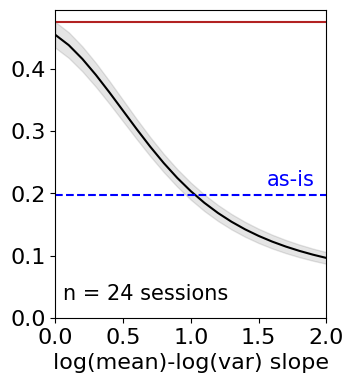

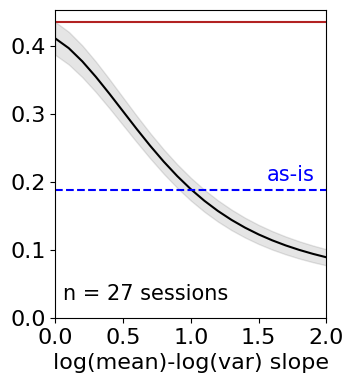

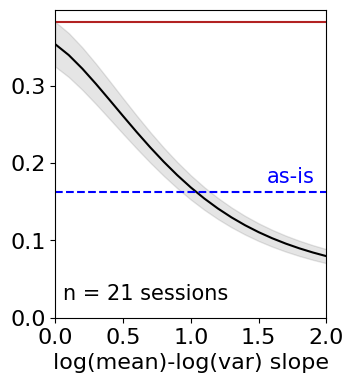

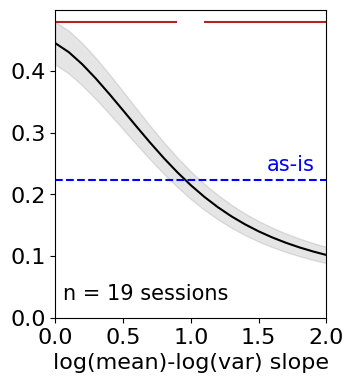

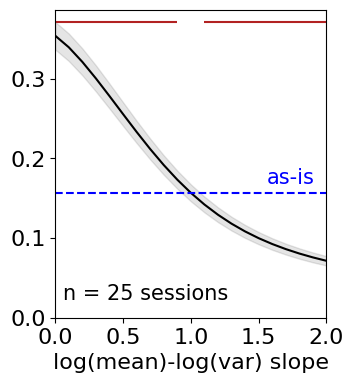

In [11]:
# effective dimensionality plot (HVA)

# V1
save_filename = 'eff_dim_DC_ABO3.pickle.gz' # all trials, centroid, trial sampling (n_trial_sampling=100), math corrected
with gzip.open(save_filename, 'rb') as f:
    eff_dim_ABO = pickle.load(f)

    list_dim_asis = eff_dim_ABO['list_dim_asis'].copy()
    list_dim_RRneuron2 = eff_dim_ABO['list_dim_RRneuron2'].copy()
    list_dim_global_asis = eff_dim_ABO['list_dim_global_asis'].copy()
    list_dim_global_RRneuron2 = eff_dim_ABO['list_dim_global_RRneuron2'].copy()
    list_dim_sam_asis = eff_dim_ABO['list_dim_sam_asis'].copy()
    list_dim_sam_RRneuron2 = eff_dim_ABO['list_dim_sam_RRneuron2'].copy()

num_sess = 32
num_trial_types = 119

# exclude session 0, 6
bool_sess = ~np.isin(range(num_sess), [0, 6])
# bool_sess = ~np.isin(range(num_sess), [0, 6]) & np.isin(range(num_sess), sess_inds_qual_all)

list_dim_asis = list_dim_asis[bool_sess]
list_dim_RRneuron2 = list_dim_RRneuron2[bool_sess]
list_dim_global_asis = list_dim_global_asis[bool_sess]
list_dim_global_RRneuron2 = list_dim_global_RRneuron2[bool_sess]
list_dim_sam_asis = list_dim_sam_asis[bool_sess]
list_dim_sam_RRneuron2 = list_dim_sam_RRneuron2[bool_sess]

fig, axes = plt.subplots(1, 1, figsize=(3.5, 4))
axes = np.array(axes).flatten()

# line plot
list_means_dim = np.nanmean(list_dim_RRneuron2, axis=(0, 2))
list_errs_dim = sem(np.nanmean(list_dim_RRneuron2, axis=2), axis=0)

axes[0].plot(list_target_slopes, list_means_dim, color='k', label='stimulus')
axes[0].fill_between(list_target_slopes, list_means_dim-list_errs_dim, list_means_dim+list_errs_dim, color='k', alpha=0.1)

axes[0].axhline(np.nanmean(list_dim_asis), color='b', linestyle='--') # as-is average

# significance
axes[0].set_ylim(0, 0.35)
list_pvals_dim_ABO = np.zeros(len(list_target_slopes))
for slope_ind, target_slope in enumerate(list_target_slopes):
    list_pvals_dim_ABO[slope_ind] = list(wilcoxon(np.nanmean(list_dim_asis, axis=1),
                                                  np.nanmean(list_dim_RRneuron2[:, slope_ind], axis=1), nan_policy='omit'))[1]
list_pvals_dim_ABO = np.array(multipletests(list_pvals_dim_ABO, method='holm')[1]) # multiple comparisons correction
list_sig_slopes_dim = list_target_slopes[list_pvals_dim_ABO < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_dim, axes=None, ax_ind=None, line_height_ratio=0.96, color='firebrick')

height = (np.nanmean(list_dim_asis)-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
axes[0].annotate('as-is', xy=(0.78, height+0.03), xycoords='axes fraction', fontsize=15, color='b')
axes[0].set_xlim(0, 2)

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=16)
axes[0].set_ylabel('Effective dimensionality\n(individual stimulus)', fontsize=19)
axes[0].tick_params('both', labelsize=16)

axes[0].annotate(f'n = {list_dim_asis.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=15, color='k')

# plt.savefig(f'code_images\\neural_variability_robustness\\svg\\effdim_VISp.svg', bbox_inches='tight')
# plt.savefig(f'code_images\\neural_variability_robustness\\png\\effdim_VISp.png', dpi=300, bbox_inches='tight')
plt.show()

# HVA
save_file_name = 'eff_dim_DC_ABO_HVA2.pickle.gz' # all trials, centroid, trial sampling (n_trial_sampling=100), math corrected
with gzip.open(save_file_name, 'rb') as f:
    eff_dim_ABO = pickle.load(f)

    list_dim_asis_HVA = eff_dim_ABO['list_dim_asis_HVA'].copy()
    list_dim_RRneuron_HVA2 = eff_dim_ABO['list_dim_RRneuron_HVA2'].copy()
    list_dim_global_asis_HVA = eff_dim_ABO['list_dim_global_asis_HVA'].copy()
    list_dim_global_RRneuron_HVA2 = eff_dim_ABO['list_dim_global_RRneuron_HVA2'].copy()
    list_dim_sam_asis_HVA = eff_dim_ABO['list_dim_sam_asis_HVA'].copy()
    list_dim_sam_RRneuron_HVA2 = eff_dim_ABO['list_dim_sam_RRneuron_HVA2'].copy()

with gzip.open('resp_matrix_ep_HVA_allensdk.pickle.gz', 'rb') as f:
    resp_matrix_ep_HVA_allensdk = pickle.load(f)

    list_empty_sess2 = dc(resp_matrix_ep_HVA_allensdk['list_empty_sess2'])
    list_num_neurons_HVA = dc(resp_matrix_ep_HVA_allensdk['list_num_neurons_HVA'])
    # print(resp_matrix_ep_HVA_allensdk['tree_variables'])
    
list_HVA_names = ['VISl', 'VISrl', 'VISal', 'VISpm', 'VISam']
list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# Wilcoxon signed-rank test (RRneuron, ABO HVA)
list_pvals_RRneuron_HVA2 = {hva: np.zeros(len(list_target_slopes)) for hva in list_HVA_names}
for area_ind, area in enumerate(list_HVA_names):
    for slope_ind, slope in enumerate(list_target_slopes):
        list_pvals_RRneuron_HVA2[area][slope_ind] = list(wilcoxon(np.nanmean(list_dim_asis_HVA[area], axis=1),
                                                                  np.nanmean(list_dim_RRneuron_HVA2[area][:, slope_ind], axis=1), nan_policy='omit'))[1]
    list_pvals_RRneuron_HVA2[area] = np.array(multipletests(list_pvals_RRneuron_HVA2[area], method='holm')[1]) # multiple comparisons correction
    
# As-is vs. RRneuron test accuracy (averaged across sessions)
for area_ind, area in enumerate(list_HVA_names):

    list_dim_asis_HVA_temp = dc(list_dim_asis_HVA[area])
    list_dim_RRneuron_HVA2_temp = dc(list_dim_RRneuron_HVA2[area])

    # exclude low quality sessions & sessions without neurons
    mask_lowq = ~np.isin(list(sess_inds_mapBO.values()), list_invalid_sess_HVA[area]['natural_scenes'])
    mask_lowq = mask_lowq & (list_num_neurons_HVA[area] > 0)
    list_dim_asis_HVA_temp = list_dim_asis_HVA[area][mask_lowq].copy()
    list_dim_RRneuron_HVA2_temp = list_dim_RRneuron_HVA2[area][mask_lowq].copy()

    fig, axes = plt.subplots(1, 1, figsize=(3.5, 4))
    axes = np.array(axes).flatten()
    
    list_means_dim = np.nanmean(list_dim_RRneuron_HVA2_temp, axis=(0, 2))
    list_errs_dim = sem(np.nanmean(list_dim_RRneuron_HVA2_temp, axis=2), axis=0)

    line, = axes[0].plot(list_target_slopes, list_means_dim, color='k')
    axes[0].fill_between(list_target_slopes, list_means_dim-list_errs_dim,
                         list_means_dim+list_errs_dim, color='k', alpha=0.1)
    axes[0].axhline(np.mean(list_dim_asis_HVA_temp), c='b', linestyle='--') # as-is average

    # significance
    axes[0].set_ylim(0, axes[0].get_ylim()[1])
    annotate_lineplot_significance(list_target_slopes[list_pvals_RRneuron_HVA2[area] < 0.05], axes=axes,
                                   ax_ind=0, line_height_ratio=0.96, color='firebrick')

    height = (np.mean(list_dim_asis_HVA_temp) - axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1] - axes[0].get_ylim()[0])
    axes[0].annotate('as-is', xy=(0.78, height+0.03), xycoords='axes fraction', fontsize=15, color='b')
    axes[0].annotate(f'n = {len(list_dim_asis_HVA_temp)} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=15, color='k')
    axes[0].set_xlim(0, 2)

    axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=16)
    # axes[0].set_ylabel('Effective dimensionality', fontsize=19)
    axes[0].tick_params('both', labelsize=16)
    
    # plt.savefig(f'code_images\\neural_variability_robustness\\svg\\effdim_{area}.svg', bbox_inches='tight')
    # plt.savefig(f'code_images\\neural_variability_robustness\\png\\effdim_{area}.png', dpi=300, bbox_inches='tight')
    plt.show()

## Supplementary Figure 15a right

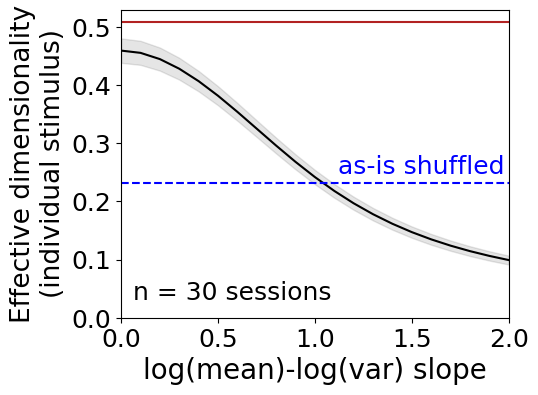

In [12]:
# effective dimensionality plot (only shuffled)

save_filename = 'eff_dim_DC_ABO_shuf2.pickle.gz' # all trials, centroid, trial sampling (n_trial_sampling=100), math corrected
with gzip.open(save_filename, 'rb') as f:
    eff_dim_ABO = pickle.load(f)

    list_dim_asis_shuf = eff_dim_ABO['list_dim_asis'].copy()
    list_dim_RRneuron2_shuf = eff_dim_ABO['list_dim_RRneuron2'].copy()
    list_dim_global_asis_shuf = eff_dim_ABO['list_dim_global_asis'].copy()
    list_dim_global_RRneuron2_shuf = eff_dim_ABO['list_dim_global_RRneuron2'].copy()
    list_dim_sam_asis_shuf = eff_dim_ABO['list_dim_sam_asis'].copy()
    list_dim_sam_RRneuron2_shuf = eff_dim_ABO['list_dim_sam_RRneuron2'].copy()

num_sess = 32
list_target_slopes = np.linspace(0, 2, 21, endpoint=True)

# exclude session 0, 6
bool_sess = ~np.isin(range(num_sess), [0, 6])

list_dim_asis_shuf = list_dim_asis_shuf[bool_sess]
list_dim_RRneuron2_shuf = list_dim_RRneuron2_shuf[bool_sess]
list_dim_global_asis_shuf = list_dim_global_asis_shuf[bool_sess]
list_dim_global_RRneuron2_shuf = list_dim_global_RRneuron2_shuf[bool_sess]
list_dim_sam_asis_shuf = list_dim_sam_asis_shuf[bool_sess]
list_dim_sam_RRneuron2_shuf = list_dim_sam_RRneuron2_shuf[bool_sess]

fig, axes = plt.subplots(1, 1, figsize=(5, 4))
axes = np.array(axes).flatten()

# 2. shuffled

# line plot

# individual manifold
list_means_dim = np.nanmean(list_dim_RRneuron2_shuf, axis=(0, 2))
list_errs_dim = sem(np.nanmean(list_dim_RRneuron2_shuf, axis=2), axis=0)

axes[0].plot(list_target_slopes, list_means_dim, color='k', label='individual\nstimulus (shuffled)')
axes[0].fill_between(list_target_slopes, list_means_dim-list_errs_dim, list_means_dim+list_errs_dim, color='k', alpha=0.1)

axes[0].axhline(np.nanmean(list_dim_asis_shuf), color='b', linestyle='--') # as-is average

# # global manifold
# list_colors_glo = ['royalblue', 'darkred']
# list_colors_glo = ['crimson', 'darkred']

# glo_ind = 0
# list_means_dim_global = np.nanmean(list_dim_global_RRneuron2_shuf[:, :, glo_ind], axis=0)
# list_errs_dim_global = sem(list_dim_global_RRneuron2_shuf[:, :, glo_ind], axis=0)

# axes[0].plot(list_target_slopes, list_means_dim_global, color=list_colors_glo[glo_ind], label='all trials (shuffled)')
# axes[0].fill_between(list_target_slopes, list_means_dim_global-list_errs_dim_global, list_means_dim_global+list_errs_dim_global, color=list_colors_glo[glo_ind], alpha=0.1)

# axes[0].axhline(np.nanmean(list_dim_global_asis_shuf[:, glo_ind]), color=list_colors_glo[glo_ind], linestyle='--') # as-is average

# glo_ind = 1
# list_means_dim_global = np.nanmean(list_dim_global_RRneuron2_shuf[:, :, glo_ind], axis=0)
# list_errs_dim_global = sem(list_dim_global_RRneuron2_shuf[:, :, glo_ind], axis=0)

# axes[0].plot(list_target_slopes, list_means_dim_global, color=list_colors_glo[glo_ind], label='centroid (shuffled)')
# axes[0].fill_between(list_target_slopes, list_means_dim_global-list_errs_dim_global, list_means_dim_global+list_errs_dim_global, color=list_colors_glo[glo_ind], alpha=0.1)

# axes[0].axhline(np.nanmean(list_dim_global_asis_shuf[:, glo_ind]), color=list_colors_glo[glo_ind], linestyle='--') # as-is average

# # trial-sampled
# list_means_dim_sam = np.nanmean(list_dim_sam_RRneuron2_shuf, axis=(0, 2))
# list_errs_dim_sam = sem(np.nanmean(list_dim_sam_RRneuron2_shuf, axis=2), axis=0)

# axes[0].plot(list_target_slopes, list_means_dim_sam, color='limegreen', label='sampled')
# axes[0].fill_between(list_target_slopes, list_means_dim_sam-list_errs_dim_sam, list_means_dim_sam+list_errs_dim_sam, color='limegreen', alpha=0.1)

# axes[0].axhline(np.nanmean(list_dim_sam_asis_shuf), color='limegreen', linestyle='--') # as-is average

# significance
axes[0].set_ylim(0, 0.53) # w/ shuffled
list_pvals_dim_ABO_shuf = np.zeros(len(list_target_slopes))
for slope_ind, target_slope in enumerate(list_target_slopes):
    list_pvals_dim_ABO_shuf[slope_ind] = list(wilcoxon(np.nanmean(list_dim_asis_shuf, axis=1),
                                                       np.nanmean(list_dim_RRneuron2_shuf[:, slope_ind], axis=1), nan_policy='omit'))[1]
list_pvals_dim_ABO_shuf = np.array(multipletests(list_pvals_dim_ABO_shuf, method='holm')[1]) # multiple comparisons correction
list_sig_slopes_dim_shuf = list_target_slopes[list_pvals_dim_ABO_shuf < 0.05].copy()
annotate_lineplot_significance(list_sig_slopes_dim_shuf, axes=axes, ax_ind=0, line_height_ratio=0.96, color='firebrick')

height_shuf = (np.nanmean(list_dim_asis_shuf)-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
axes[0].annotate('as-is shuffled', xy=(0.56, height_shuf+0.03), xycoords='axes fraction', fontsize=18, color='b')

# for glo_ind in [0, 1]:
#     if glo_ind == 0:
#         list_pvals_dim_glo_ABO_shuf = np.zeros(len(list_target_slopes))
#         list_pvals_dim_glo_ABO_toshuf = np.zeros(len(list_target_slopes))
#         for slope_ind, target_slope in enumerate(list_target_slopes):
#             list_pvals_dim_glo_ABO_shuf[slope_ind] = list(wilcoxon(list_dim_global_asis_shuf[:, glo_ind], list_dim_global_RRneuron2_shuf[:, slope_ind, glo_ind], nan_policy='omit'))[1]
#             list_pvals_dim_glo_ABO_toshuf[slope_ind] = list(wilcoxon(list_dim_global_RRneuron2[:, slope_ind, glo_ind], list_dim_global_RRneuron2_shuf[:, slope_ind, glo_ind], nan_policy='omit'))[1]
#         list_pvals_dim_glo_ABO_shuf = np.array(multipletests(list_pvals_dim_glo_ABO_shuf, method='holm')[1]) # multiple comparisons correction
#         list_sig_slopes_dim_glo_shuf = list_target_slopes[list_pvals_dim_glo_ABO_shuf < 0.05].copy()
#         annotate_lineplot_significance(list_sig_slopes_dim_glo_shuf, axes=None, ax_ind=None, line_height_ratio=0.94-0.02*glo_ind, color=list_colors_glo[glo_ind])
#         list_pvals_dim_glo_ABO_toshuf = np.array(multipletests(list_pvals_dim_glo_ABO_toshuf, method='holm')[1]) # multiple comparisons correction
#         list_sig_slopes_dim_glo_toshuf = list_target_slopes[list_pvals_dim_glo_ABO_toshuf < 0.05].copy()
#         annotate_lineplot_significance(list_sig_slopes_dim_glo_toshuf, axes=None, ax_ind=None, line_height_ratio=0.92, color='limegreen')
#         # height = (np.nanmean(list_dim_global_asis[:, glo_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
#         # # axes[0].annotate('as-is', xy=(0.82, height+0.03), xycoords='axes fraction', fontsize=18, color='b')
#         # axes[0].annotate('as-is', xy=(0.79, height+0.03), xycoords='axes fraction', fontsize=18, color='k') # w/ shuffled

# list_pvals_dim_sam_ABO_shuf = np.zeros(len(list_target_slopes))
# for slope_ind, target_slope in enumerate(list_target_slopes):
#     list_pvals_dim_sam_ABO_shuf[slope_ind] = list(wilcoxon(np.nanmean(list_dim_sam_asis_shuf, axis=1),
#                                                   np.nanmean(list_dim_sam_RRneuron2_shuf[:, slope_ind], axis=1), nan_policy='omit'))[1]
# list_pvals_dim_sam_ABO_shuf = np.array(multipletests(list_pvals_dim_sam_ABO_shuf, method='holm')[1]) # multiple comparisons correction
# list_sig_slopes_dim_sam_shuf = list_target_slopes[list_pvals_dim_sam_ABO_shuf < 0.05].copy()
# annotate_lineplot_significance(list_sig_slopes_dim_sam_shuf, axes=None, ax_ind=None, line_height_ratio=0.96, color='limegreen')
# height_global = (np.nanmean(list_dim_global_asis_shuf[:, glo_ind])-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
# axes[0].annotate('as-is centroid', xy=(0.03, height_global-0.1), xycoords='axes fraction', fontsize=18, color='crimson')
# height_sam = (np.nanmean(list_dim_sam_asis_shuf)-axes[0].get_ylim()[0]) / (axes[0].get_ylim()[1]-axes[0].get_ylim()[0])
# axes[0].annotate('as-is sampled', xy=(0.55, height_sam+0.03), xycoords='axes fraction', fontsize=18, color='limegreen')

axes[0].set_xlim(0, 2)

axes[0].set_xlabel('log(mean)-log(var) slope', fontsize=20)
axes[0].set_ylabel('Effective dimensionality\n(individual stimulus)', fontsize=19)
# axes[0].set_ylabel('Effective dimensionality\n(all trials)', fontsize=19)
axes[0].tick_params('both', labelsize=18)

axes[0].annotate(f'n = {list_dim_asis.shape[0]} sessions', xy=(0.03, 0.06), xycoords='axes fraction', fontsize=18, color='k')
# axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1), prop={'size': 14})

# plt.savefig('code_images\\neural_variability_robustness\\svg\\onlyshuf_effdim.svg', bbox_inches='tight')
# plt.savefig('code_images\\neural_variability_robustness\\png\\onlyshuf_effdim.png', dpi=300, bbox_inches='tight')
plt.show()